In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


In [7]:
import pulp
import pandas as pd
import numpy as np

def optimize_bess_arbitrage(prices, capacity_mwh=2.0, max_power_mw=1.0, efficiency=0.92):
    timesteps = range(len(prices))
    model = pulp.LpProblem("BESS_Arbitrage_Optimization", pulp.LpMaximize)

    p_charge = pulp.LpVariable.dicts("Charge", timesteps, lowBound=0, upBound=max_power_mw)
    p_discharge = pulp.LpVariable.dicts("Discharge", timesteps, lowBound=0, upBound=max_power_mw)
    soc = pulp.LpVariable.dicts("SoC", range(len(prices) + 1), lowBound=0, upBound=capacity_mwh)
    is_charging = pulp.LpVariable.dicts("IsCharging", timesteps, cat='Binary')

    model += pulp.lpSum(
        prices[t] * (p_discharge[t] * np.sqrt(efficiency) - p_charge[t] / np.sqrt(efficiency))
        for t in timesteps
    )

    model += (soc[0] == capacity_mwh * 0.5)
    M = max_power_mw * 2

    for t in timesteps:
        model += (soc[t+1] == soc[t] + p_charge[t] * np.sqrt(efficiency) - p_discharge[t] / np.sqrt(efficiency))
        model += (p_charge[t] <= M * is_charging[t])
        model += (p_discharge[t] <= M * (1 - is_charging[t]))

    model += (soc[len(prices)] >= capacity_mwh * 0.5)
    model.solve(pulp.PULP_CBC_CMD(msg=0))

    results = []
    for t in timesteps:
        results.append({
            "Hour": t,
            "Price (€/MWh)": prices[t],
            "Charge (MW)": p_charge[t].varValue,
            "Discharge (MW)": p_discharge[t].varValue,
            "SoC (MWh)": soc[t+1].varValue
        })
    return pd.DataFrame(results), pulp.LpStatus[model.status]

print("✅ موتور بهینه‌سازی مستقیماً در نوت‌بوک بارگذاری شد!")

✅ موتور بهینه‌سازی مستقیماً در نوت‌بوک بارگذاری شد!


In [9]:
import pulp
import pandas as pd
import numpy as np

def optimize_bess_arbitrage(prices, capacity_mwh=2.0, max_power_mw=1.0, efficiency=0.92):
    timesteps = range(len(prices))
    model = pulp.LpProblem("BESS_Arbitrage_Optimization", pulp.LpMaximize)

    p_charge = pulp.LpVariable.dicts("Charge", timesteps, lowBound=0, upBound=max_power_mw)
    p_discharge = pulp.LpVariable.dicts("Discharge", timesteps, lowBound=0, upBound=max_power_mw)
    soc = pulp.LpVariable.dicts("SoC", range(len(prices) + 1), lowBound=0, upBound=capacity_mwh)
    is_charging = pulp.LpVariable.dicts("IsCharging", timesteps, cat='Binary')

    model += pulp.lpSum(
        prices[t] * (p_discharge[t] * np.sqrt(efficiency) - p_charge[t] / np.sqrt(efficiency))
        for t in timesteps
    )

    model += (soc[0] == capacity_mwh * 0.5)
    M = max_power_mw * 2

    for t in timesteps:
        model += (soc[t+1] == soc[t] + p_charge[t] * np.sqrt(efficiency) - p_discharge[t] / np.sqrt(efficiency))
        model += (p_charge[t] <= M * is_charging[t])
        model += (p_discharge[t] <= M * (1 - is_charging[t]))

    model += (soc[len(prices)] >= capacity_mwh * 0.5)
    model.solve(pulp.PULP_CBC_CMD(msg=0))

    results = []
    for t in timesteps:
        results.append({
            "Hour": t,
            "Price (€/MWh)": prices[t],
            "Charge (MW)": p_charge[t].varValue,
            "Discharge (MW)": p_discharge[t].varValue,
            "SoC (MWh)": soc[t+1].varValue
        })
    return pd.DataFrame(results), pulp.LpStatus[model.status]

print("✅ موتور بهینه‌سازی با موفقیت بارگذاری شد و آماده اجراست!")

✅ موتور بهینه‌سازی با موفقیت بارگذاری شد و آماده اجراست!


In [12]:
import os
os.makedirs("src", exist_ok=True)

In [13]:
%%writefile src/optimization_engine.py
import pulp
import pandas as pd
import numpy as np

def optimize_bess_arbitrage(prices, capacity_mwh=2.0, max_power_mw=1.0, efficiency=0.92):
    timesteps = range(len(prices))
    model = pulp.LpProblem("BESS_Arbitrage_Optimization", pulp.LpMaximize)

    p_charge = pulp.LpVariable.dicts("Charge", timesteps, lowBound=0, upBound=max_power_mw)
    p_discharge = pulp.LpVariable.dicts("Discharge", timesteps, lowBound=0, upBound=max_power_mw)
    soc = pulp.LpVariable.dicts("SoC", range(len(prices) + 1), lowBound=0, upBound=capacity_mwh)
    is_charging = pulp.LpVariable.dicts("IsCharging", timesteps, cat='Binary')

    model += pulp.lpSum(
        prices[t] * (p_discharge[t] * np.sqrt(efficiency) - p_charge[t] / np.sqrt(efficiency))
        for t in timesteps
    )

    model += (soc[0] == capacity_mwh * 0.5)
    M = max_power_mw * 2

    for t in timesteps:
        model += (soc[t+1] == soc[t] + p_charge[t] * np.sqrt(efficiency) - p_discharge[t] / np.sqrt(efficiency))
        model += (p_charge[t] <= M * is_charging[t])
        model += (p_discharge[t] <= M * (1 - is_charging[t]))

    model += (soc[len(prices)] >= capacity_mwh * 0.5)
    model.solve(pulp.PULP_CBC_CMD(msg=0))

    results = []
    for t in timesteps:
        results.append({
            "Hour": t,
            "Price (€/MWh)": prices[t],
            "Charge (MW)": p_charge[t].varValue,
            "Discharge (MW)": p_discharge[t].varValue,
            "SoC (MWh)": soc[t+1].varValue
        })
    return pd.DataFrame(results), pulp.LpStatus[model.status]

Writing src/optimization_engine.py


In [14]:
import sys
if '.' not in sys.path:
    sys.path.append('.')

from src.optimization_engine import optimize_bess_arbitrage
print("🚀 حالا بدون هیچ خطایی آماده‌ی اجراست!")

🚀 حالا بدون هیچ خطایی آماده‌ی اجراست!


In [15]:
import sys
import os

# اضافه کردن مسیر جاری پروژه به پایتون
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)

# حالا ماژول به راحتی ایمپورت می‌شود
from src.optimization_engine import optimize_bess_arbitrage

print("✅ ماژول با موفقیت و بدون خطا ایمپورت شد!")

✅ ماژول با موفقیت و بدون خطا ایمپورت شد!


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.optimization_engine import optimize_bess_arbitrage

print("Libraries loaded successfully.")

Libraries loaded successfully.


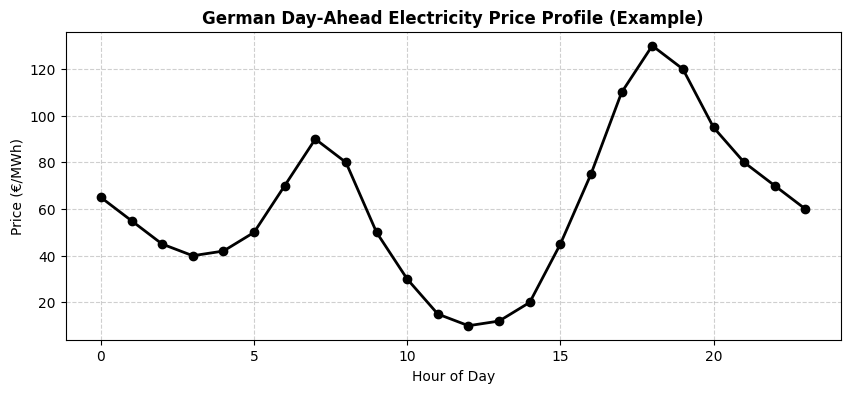

In [17]:
# Simulated 24-hour German Day-Ahead Electricity Prices (€/MWh)
hours = list(range(24))
prices = [
    65, 55, 45, 40, 42, 50, 70, 90,   # Night & Morning ramp
    80, 50, 30, 15, 10, 12, 20, 45,   # Solar dip (midday cheap energy)
    75, 110, 130, 120, 95, 80, 70, 60 # Evening peak
]

df_prices = pd.DataFrame({"Hour": hours, "Price (€/MWh)": prices})

# Plot price curve
plt.figure(figsize=(10, 4))
plt.plot(df_prices["Hour"], df_prices["Price (€/MWh)"], marker="o", color="black", linewidth=2)
plt.title("German Day-Ahead Electricity Price Profile (Example)", fontsize=12, fontweight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Price (€/MWh)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [18]:
# BESS technical specifications
CAPACITY_MWH = 2.0
MAX_POWER_MW = 1.0
EFFICIENCY = 0.92

# Run optimization model
results_df, status = optimize_bess_arbitrage(
    prices=prices,
    capacity_mwh=CAPACITY_MWH,
    max_power_mw=MAX_POWER_MW,
    efficiency=EFFICIENCY
)

print(f"Optimization Status: {status}")
results_df.head(10)

Optimization Status: Optimal


,Hour,Price (€/MWh),Charge (MW),Discharge (MW),SoC (MWh)
0,0,65,0.000000,0.959166,0.000000
1,1,55,0.000000,0.000000,0.000000
2,2,45,0.085144,0.000000,0.081667
3,3,40,1.000000,0.000000,1.040834
4,4,42,1.000000,0.000000,2.000000
5,5,50,0.000000,0.000000,2.000000
6,6,70,0.000000,0.000000,2.000000
7,7,90,0.000000,1.000000,0.957428
8,8,80,0.000000,0.918333,0.000000
9,9,50,0.000000,0.000000,0.000000


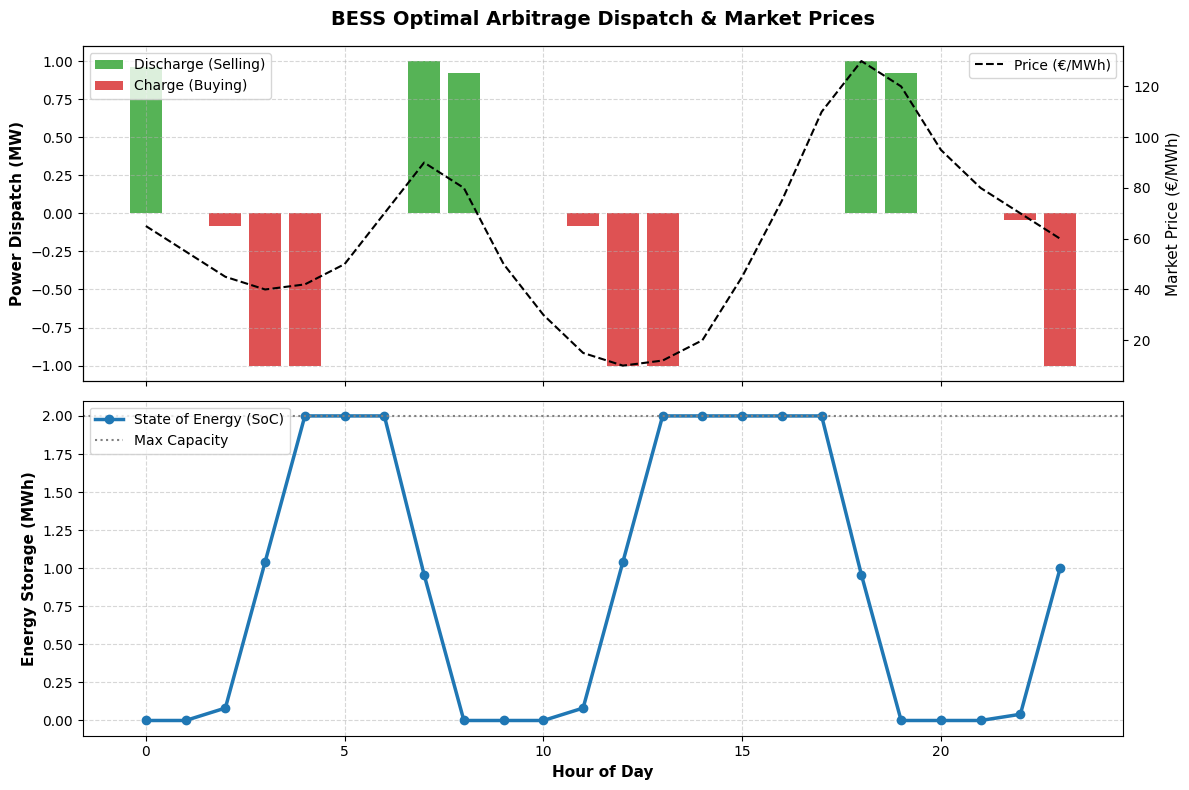

💰 Total Daily Arbitrage Gross Revenue: €267.57


In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Power Dispatch vs Prices
ax1.bar(results_df['Hour'], results_df['Discharge (MW)'], color='#2ca02c', alpha=0.8, label='Discharge (Selling)')
ax1.bar(results_df['Hour'], -results_df['Charge (MW)'], color='#d62728', alpha=0.8, label='Charge (Buying)')
ax1.set_ylabel('Power Dispatch (MW)', fontsize=11, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

ax_twin = ax1.twinx()
ax_twin.plot(results_df['Hour'], results_df['Price (€/MWh)'], color='black', linestyle='--', linewidth=1.5, label='Price (€/MWh)')
ax_twin.set_ylabel('Market Price (€/MWh)', fontsize=11)
ax_twin.legend(loc='upper right')
ax1.set_title('BESS Optimal Arbitrage Dispatch & Market Prices', fontsize=14, fontweight='bold', pad=15)

# Plot 2: State of Charge (SoC)
ax2.plot(results_df['Hour'], results_df['SoC (MWh)'], color='#1f77b4', marker='o', linewidth=2.5, label='State of Energy (SoC)')
ax2.axhline(CAPACITY_MWH, color='grey', linestyle=':', label='Max Capacity')
ax2.set_ylabel('Energy Storage (MWh)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Hour of Day', fontsize=11, fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Calculate total arbitrage revenue
total_revenue = (results_df['Discharge (MW)'] * results_df['Price (€/MWh)'] * np.sqrt(EFFICIENCY)).sum() - \
                (results_df['Charge (MW)'] * results_df['Price (€/MWh)'] / np.sqrt(EFFICIENCY)).sum()

print(f"💰 Total Daily Arbitrage Gross Revenue: €{total_revenue:,.2f}")

In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pulp

# ۱. ساخت پوشه outputs اگر وجود نداشته باشد
os.makedirs("outputs", exist_ok=True)

print("📁 پوشه outputs بررسی و آماده شد.")

# ۲. تعریف داده‌های قیمت بازار آلمان (Day-Ahead Prices)
hours = list(range(24))
prices = [
    65, 55, 45, 40, 42, 50, 70, 90,
    80, 50, 30, 15, 10, 12, 20, 45,
    75, 110, 130, 120, 95, 80, 70, 60
]

df_prices = pd.DataFrame({"Hour": hours, "Price (€/MWh)": prices})

# ذخیره جدول قیمت‌ها به صورت CSV
df_prices.to_csv("outputs/market_prices.csv", index=False)

# ۳. اجرای بهینه‌سازی MILP برای آرکیتراژ
CAPACITY_MWH = 2.0
MAX_POWER_MW = 1.0
EFFICIENCY = 0.92
timesteps = range(len(prices))

model = pulp.LpProblem("BESS_Arbitrage_Optimization", pulp.LpMaximize)
p_charge = pulp.LpVariable.dicts("Charge", timesteps, lowBound=0, upBound=MAX_POWER_MW)
p_discharge = pulp.LpVariable.dicts("Discharge", timesteps, lowBound=0, upBound=MAX_POWER_MW)
soc = pulp.LpVariable.dicts("SoC", range(len(prices) + 1), lowBound=0, upBound=CAPACITY_MWH)
is_charging = pulp.LpVariable.dicts("IsCharging", timesteps, cat='Binary')

model += pulp.lpSum(
    prices[t] * (p_discharge[t] * np.sqrt(EFFICIENCY) - p_charge[t] / np.sqrt(EFFICIENCY))
    for t in timesteps
)

model += (soc[0] == CAPACITY_MWH * 0.5)
M = MAX_POWER_MW * 2

for t in timesteps:
    model += (soc[t+1] == soc[t] + p_charge[t] * np.sqrt(EFFICIENCY) - p_discharge[t] / np.sqrt(EFFICIENCY))
    model += (p_charge[t] <= M * is_charging[t])
    model += (p_discharge[t] <= M * (1 - is_charging[t]))

model += (soc[len(prices)] >= CAPACITY_MWH * 0.5)
model.solve(pulp.PULP_CBC_CMD(msg=0))

results = []
for t in timesteps:
    results.append({
        "Hour": t,
        "Price (€/MWh)": prices[t],
        "Charge (MW)": p_charge[t].varValue,
        "Discharge (MW)": p_discharge[t].varValue,
        "SoC (MWh)": soc[t+1].varValue
    })

results_df = pd.DataFrame(results)

# ذخیره جدول نتایج بهینه‌سازی به صورت CSV
results_df.to_csv("outputs/optimization_results.csv", index=False)

# ۴. رسم و ذخیره تصویر پروفایل قیمت بازار
plt.figure(figsize=(10, 4))
plt.plot(df_prices["Hour"], df_prices["Price (€/MWh)"], marker="o", color="black", linewidth=2)
plt.title("German Day-Ahead Electricity Price Profile", fontsize=12, fontweight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Price (€/MWh)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("outputs/market_prices_chart.png", dpi=300)
plt.close()

# ۵. رسم و ذخیره تصویر تخصصی دیسپچ و وضعیت باتری (SoC)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.bar(results_df['Hour'], results_df['Discharge (MW)'], color='#2ca02c', alpha=0.8, label='Discharge (Selling)')
ax1.bar(results_df['Hour'], -results_df['Charge (MW)'], color='#d62728', alpha=0.8, label='Charge (Buying)')
ax1.set_ylabel('Power Dispatch (MW)', fontsize=11, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

ax_twin = ax1.twinx()
ax_twin.plot(results_df['Hour'], results_df['Price (€/MWh)'], color='black', linestyle='--', linewidth=1.5, label='Price (€/MWh)')
ax_twin.set_ylabel('Market Price (€/MWh)', fontsize=11)
ax_twin.legend(loc='upper right')
ax1.set_title('BESS Optimal Arbitrage Dispatch & Market Prices', fontsize=14, fontweight='bold', pad=15)

ax2.plot(results_df['Hour'], results_df['SoC (MWh)'], color='#1f77b4', marker='o', linewidth=2.5, label='State of Energy (SoC)')
ax2.axhline(CAPACITY_MWH, color='grey', linestyle=':', label='Max Capacity')
ax2.set_ylabel('Energy Storage (MWh)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Hour of Day', fontsize=11, fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("outputs/bess_dispatch_chart.png", dpi=300)
plt.close()

print("✅ تمامی تصاویر و جداول با موفقیت در پوشه outputs ذخیره شدند!")

📁 پوشه outputs بررسی و آماده شد.
✅ تمامی تصاویر و جداول با موفقیت در پوشه outputs ذخیره شدند!
